# project 3 Transaction Data Distribution Analysis

### Objective
The purpose of this analysis is to understand the transaction data using
different probability distributions, transformation techniques and
statistical plots.

The analysis covers:
1. Bernoulli and Binomial distributions
2. Poisson distribution
3. Log-Normal and Power Law distributions
4. Q-Q Plot and normality testing
5. Box-Cox transformation
6. Z-scores and probability estimation
7. PDF and CDF
8. Final distribution comparison

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_excel('/content/spread_locator_dataset.xlsx')

In [3]:
df

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success
...,...,...,...,...,...,...,...
215,10c2a8f2-89d0-485c-bf8f-9508d32a02fc,CUST5563,4356.76,2023-01-12,2,South,Fail
216,5618814b-f7e2-424d-9617-9fc8d8643370,CUST8579,2025.53,2023-01-29,6,South,Fail
217,5636c9e7-9d54-4654-9c89-fdf31be87d96,CUST5092,2648.08,2023-01-30,1,West,Fail
218,6ba09450-a455-4983-bbad-3dad292cc839,CUST2235,2338.62,2023-01-26,3,North,Success


In [4]:
df.describe()

,transaction_amount,transaction_date,transaction_count
count,220.000000,220,220.000000
mean,3365.192409,2023-01-15 17:14:10.909090816,2.854545
min,804.420000,2023-01-01 00:00:00,0.000000
25%,2124.205000,2023-01-07 00:00:00,1.750000
50%,3077.715000,2023-01-16 00:00:00,3.000000
75%,3950.737500,2023-01-23 06:00:00,4.000000
max,20462.840000,2023-01-31 00:00:00,9.000000
std,1985.705409,NaN,1.797189


**1.Fit THE DATA  BERNOULI AND BINOMIAL DISTRIBUTION(TRANSACTION **O**CCURANCE & WEEKLY COUNTED**

1.1 BERNOULI DISTRIBUTION
# Bernoulli distribution tab use hoti hai jab sirf 2 possible outcomes ho.
Example:
# Success = 1
# Fail = 0

Success probability: 0.4455
Failure probability: 0.5545

Status counts:
transaction_status
Fail       122
Success     98
Name: count, dtype: int64


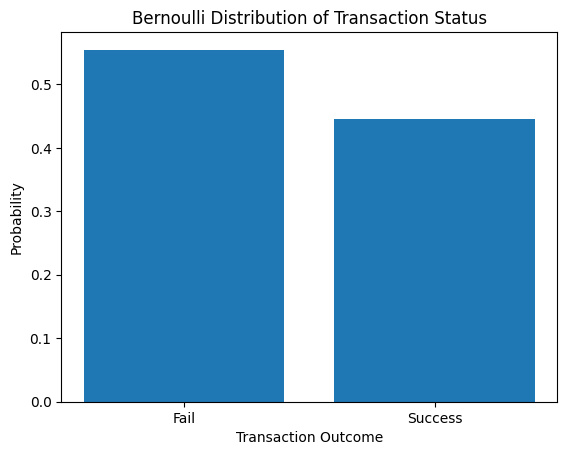

In [5]:
from scipy import stats
from scipy.stats import bernoulli
import matplotlib.pyplot as plt
# Convert transaction status into binary form
df["success"] = (df["transaction_status"] == "Success").astype(int)

success_rate = df["success"].mean()

print("Success probability:", round(success_rate, 4))
print("Failure probability:", round(1 - success_rate, 4))

print("\nStatus counts:")
print(df["transaction_status"].value_counts())
# BERNOULI VISUALIZATION
x = [0, 1]
probabilities = [1 - success_rate, success_rate]

plt.bar(x, probabilities)
plt.xticks([0, 1], ["Fail", "Success"])
plt.xlabel("Transaction Outcome")
plt.ylabel("Probability")
plt.title("Bernoulli Distribution of Transaction Status")
plt.show()

# conclusion
The transaction status has two possible outcomes: Success and Fail.
The probability of a successful transaction is approximately 44.55%,
while the probability of failure is approximately 55.45%.
Therefore, the transaction status can be represented using a Bernoulli distribution.

# 1.2 BINOMIAL DISTRIBUTION
BINOMIAL DISTRIBUTION BASICALLY MULTIPLE BERNOULI TRIALS KA TOTAL RESULT COUNT KARTA HA .

EXAMPLE ❎ 10 TRANSACTION ME KITNA SUCCESS HUI ?

In [6]:
df["transaction_date"] =pd.to_datetime(df["transaction_date"])
weekly_count = (
    df.groupby(df["transaction_date"].dt.to_period("W"))["transaction_count"]
    .sum()
)

print("Weekly transaction counts:")
print(weekly_count)

Weekly transaction counts:
transaction_date
2022-12-26/2023-01-01     17
2023-01-02/2023-01-08    156
2023-01-09/2023-01-15    130
2023-01-16/2023-01-22    143
2023-01-23/2023-01-29    130
2023-01-30/2023-02-05     52
Freq: W-SUN, Name: transaction_count, dtype: int64


In [7]:
# Weekly count directly binomial variable nahi hota because Binomial distribution ke liye fixed number of trials n hona chahiye
# now we observed maximun weekly count (n) approxiamtely binomial fit
n = int(weekly_count.max())
p = weekly_count.mean() / n

print("Number of trials (n):", n)
print("Estimated probability (p):", round(p, 4))

Number of trials (n): 156
Estimated probability (p): 0.6709


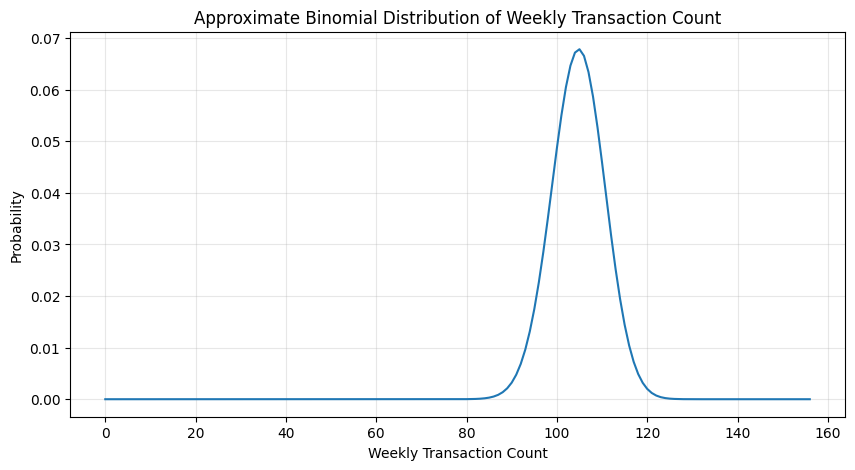

In [8]:
# visulazition
from scipy.stats import binom
x = np.arange(0, n + 1)

binomial_prob = binom.pmf(x, n, p)

plt.figure(figsize=(10, 5))
plt.plot(x, binomial_prob)
plt.xlabel("Weekly Transaction Count")
plt.ylabel("Probability")
plt.title("Approximate Binomial Distribution of Weekly Transaction Count")
plt.grid(alpha=0.3)
plt.show()

# conclusion
The weekly transaction count was approximated using a Binomial model.
The estimated success probability is about 0.671.

Since the number of weekly observations is small and the number of
trials is not naturally fixed across weeks, this Binomial fit should
be treated as an approximate model rather than an exact representation.

**2. FIT THE DATA IN POISSION DISTRIBUTION ACCORDING TO NUMBER OF **T**RANSACTION PER DAY**
# POISSON DISTRIBUTION GENERALLY FIXED TIME INTERVAL ME EVENTS KITNI BAAAR OCCUR HUWA HA CHECK KARNE KO USE HOTA HA

In [9]:
daily_transactions = df.groupby("transaction_date").size()

lambda_poisson = daily_transactions.mean()

print("Average transactions per day (lambda):",
      round(lambda_poisson, 4))

print("\nDaily transaction counts:")
print(daily_transactions)

Average transactions per day (lambda): 7.0968

Daily transaction counts:
transaction_date
2023-01-01     6
2023-01-02    12
2023-01-03    10
2023-01-04     7
2023-01-05     9
2023-01-06     6
2023-01-07     7
2023-01-08     5
2023-01-09    10
2023-01-10     8
2023-01-11     6
2023-01-12     4
2023-01-13     5
2023-01-14     6
2023-01-15     5
2023-01-16     5
2023-01-17     7
2023-01-18    12
2023-01-19     8
2023-01-20     6
2023-01-21     6
2023-01-22     8
2023-01-23     7
2023-01-24     5
2023-01-25     3
2023-01-26     6
2023-01-27     5
2023-01-28    10
2023-01-29    10
2023-01-30    10
2023-01-31     6
dtype: int64


# SO THE VALUE OF λ ≈ 7.10 transactions/daY
# NOW PLOTING THE POISSON PLOT

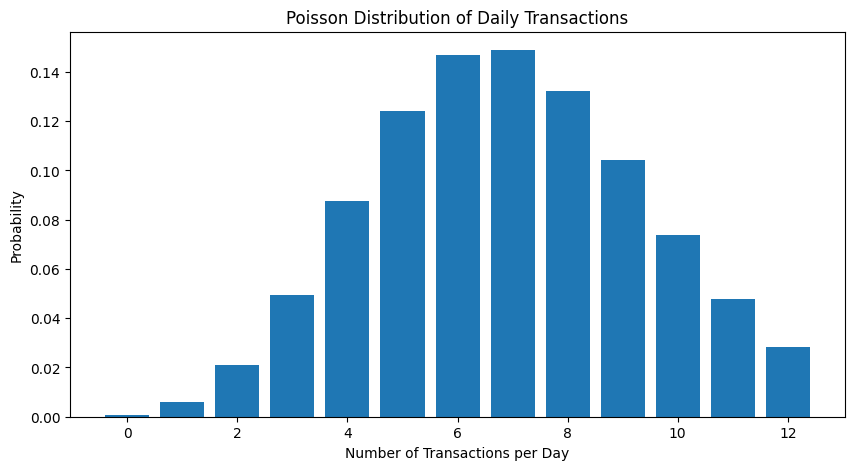

In [10]:
from scipy.stats import poisson
x = np.arange(0, daily_transactions.max() + 1)

poisson_prob = poisson.pmf(x, lambda_poisson)

plt.figure(figsize=(10, 5))
plt.bar(x, poisson_prob)
plt.xlabel("Number of Transactions per Day")
plt.ylabel("Probability")
plt.title("Poisson Distribution of Daily Transactions")
plt.show()

# conclusion

The average number of transactions per day is approximately 7.10.
Therefore, a Poisson distribution with lambda = 7.10 was fitted
to the daily transaction counts.

The Poisson model is suitable for representing event counts
occurring during a fixed time period such as one day.

**3. MODEL TRANSACTION AMOUNTS USING LOG NORMAL AND POWER LOW DISTRIBUTION**

# 3A LOG NORMAL

In [11]:
amounts = df["transaction_amount"].dropna()

print(amounts.describe())


count      220.000000
mean      3365.192409
std       1985.705409
min        804.420000
25%       2124.205000
50%       3077.715000
75%       3950.737500
max      20462.840000
Name: transaction_amount, dtype: float64


In [12]:
log_shape, log_loc, log_scale = stats.lognorm.fit(
    amounts,
    floc=0
)

print("Log-Normal parameters:")
print("Shape:", round(log_shape, 4))
print("Location:", round(log_loc, 4))
print("Scale:", round(log_scale, 4))

Log-Normal parameters:
Shape: 0.4749
Location: 0
Scale: 2983.1591


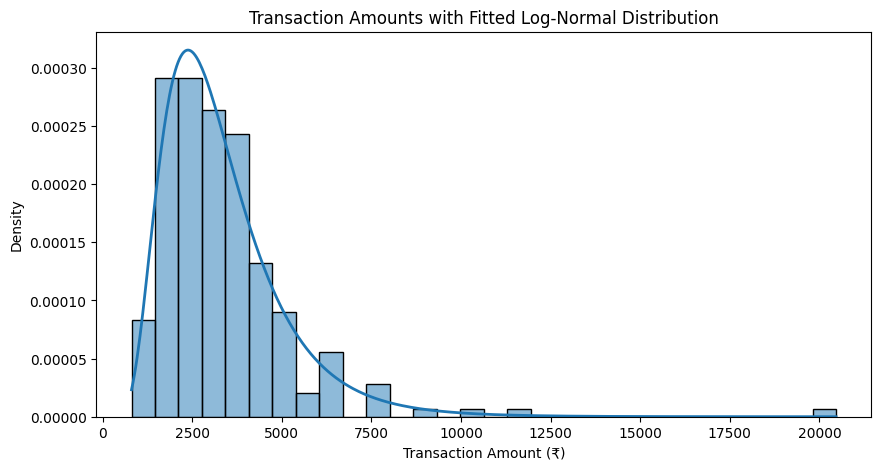

In [13]:
import seaborn as sns
x = np.linspace(amounts.min(), amounts.max(), 500)

lognormal_pdf = stats.lognorm.pdf(
    x,
    log_shape,
    loc=log_loc,
    scale=log_scale
)

plt.figure(figsize=(10, 5))
sns.histplot(amounts, bins=30, stat="density", alpha=0.5)
plt.plot(x, lognormal_pdf, linewidth=2)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Density")
plt.title("Transaction Amounts with Fitted Log-Normal Distribution")
plt.show()

# 3b power law distribution

power law model check karne ke liya hum transaction amount ka minium vakue xmin use karenge

In [14]:
xmin = amounts.min()

alpha = len(amounts) / np.sum(
    np.log(amounts / xmin)
)

print("Power Law exponent (alpha):", round(alpha, 4))
print("Minimum value (xmin):", round(xmin, 2))

Power Law exponent (alpha): 0.763
Minimum value (xmin): 804.42


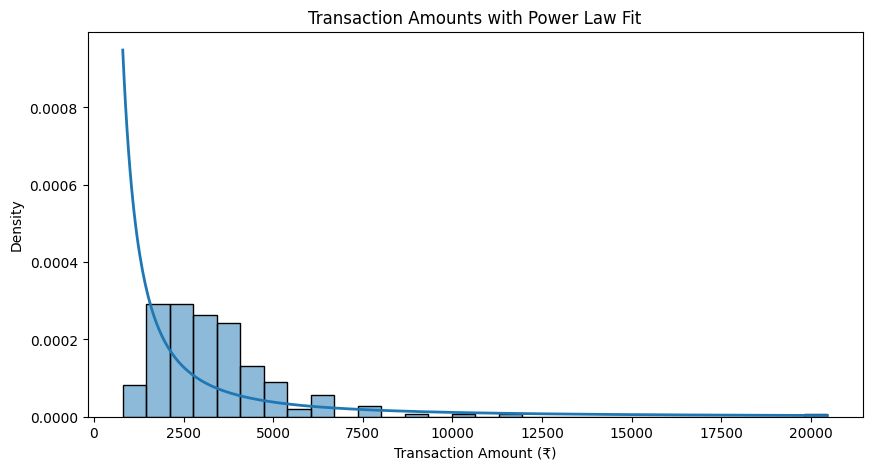

In [15]:
powerlaw_pdf = (
    alpha * xmin**alpha / x**(alpha + 1)
)

plt.figure(figsize=(10, 5))
sns.histplot(amounts, bins=30, stat="density", alpha=0.5)
plt.plot(x, powerlaw_pdf, linewidth=2)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Density")
plt.title("Transaction Amounts with Power Law Fit")
plt.show()

# now compare log normal vs power law

In [18]:
# Log-likelihood for Log-Normal
lognormal_ll = np.sum(
    stats.lognorm.logpdf(
        amounts,
        log_shape,
        loc=log_loc,
        scale=log_scale))

# Log-likelihood for Power Law
powerlaw_ll = np.sum(
    np.log(
        alpha * xmin**alpha /
        (amounts ** (alpha + 1))))

# AIC
aic_lognormal = 2 * 2 - 2 * lognormal_ll
aic_powerlaw = 2 * 1 - 2 * powerlaw_ll

print("Log-Normal AIC:", round(aic_lognormal, 2))
print("Power Law AIC:", round(aic_powerlaw, 2))

Log-Normal AIC: 3821.03
Power Law AIC: 4081.34


# conclusion

The Log-Normal model has a lower AIC than the Power Law model.
A lower AIC indicates a better relative fit among the models being compared.

Therefore, for this dataset, the Log-Normal distribution provides a
better fit to transaction amounts than the simple Power Law model.

**4.GENERATE AND  INTERPRET  Q-Q PLOT TO  TEST   NORMALITY.**
# Q-Q plot check karta hai ki data approximately normal distribution ko follow karta hai ya nahi.

NORMALITY TEST

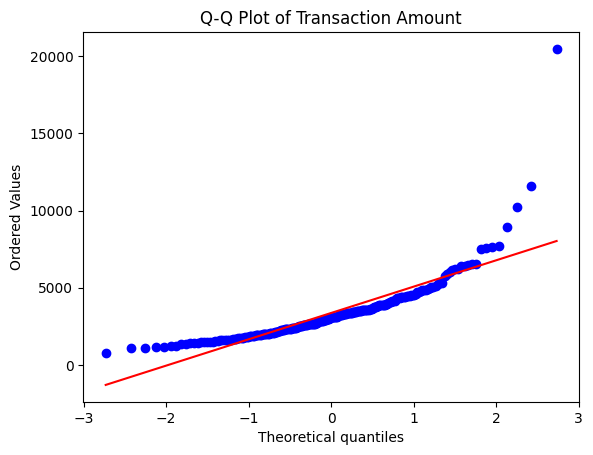

transaction amount is not normally distributed


In [22]:
from scipy.stats import probplot

data = df["transaction_amount"]

probplot(data, dist="norm", plot=plt)

plt.title("Q-Q Plot of Transaction Amount")
plt.show()

print('transaction amount is not normally distributed')

### Conclusion (Normality Test)

* **Q-Q Plot interpretation**: Since the blue data points significantly curve away from the red straight line (especially at both ends), the transaction amount does not follow a normal distribution.
* **Statistical Check**: The plot shows a clear right-skew (heavy right tail), meaning there are several very high transaction values compared to the average transaction.

5**. APPLY BOX COX TRANSFORM TO STABILIZE VARIANCE**

# Data ki variance ko stabilize karna aur distribution ko more symmetric/normal banana.

 BOX-COX Lambda: -0.18083390743966327


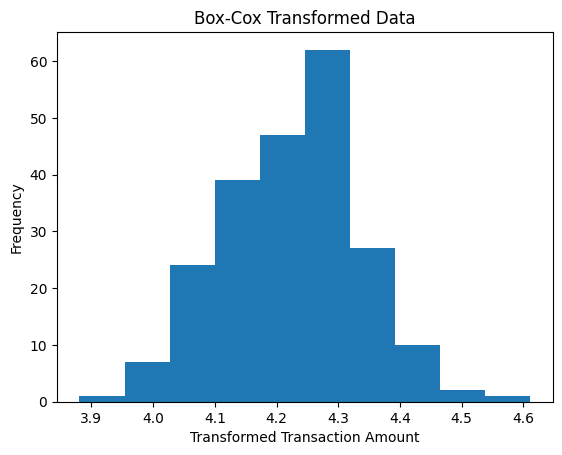

In [26]:
from scipy.stats import boxcox


data = df["transaction_amount"]

new_data, lam = boxcox(data)

print(" BOX-COX Lambda:", lam)

plt.hist(new_data, bins=10)
plt.xlabel("Transformed Transaction Amount")
plt.ylabel("Frequency")
plt.title("Box-Cox Transformed Data")
plt.show()

**6. Calculate Z-scores for transaction amounts and compute probability of transactions exceeding ₹5000**.
Formula:
Z=σX−μ​/
	​


In [32]:
from scipy.stats import norm

mean_amount = amounts.mean()
std_amount = amounts.std()
amount_limit = 5000

df["z_score"] = (df["transaction_amount"] - mean_amount) / std_amount
z_5000 = (amount_limit - mean_amount) / std_amount

print("Mean transaction amount:", round(mean_amount, 2))
print("Standard deviation:", round(std_amount, 2))
print("Z-score for ₹5000:", round(z_5000, 4))

probability = 1 - norm.cdf(z_5000)
print("Probability of transaction > ₹5000:", probability)

Mean transaction amount: 3365.19
Standard deviation: 1985.71
Z-score for ₹5000: 0.8233
Probability of transaction > ₹5000: 0.20517209567554384


# CONCLUSION

The Z-score of ₹5000 is approximately 0.82, meaning that ₹5000 is
around 0.82 standard deviations above the sample mean.

Using a normal-distribution approximation, the estimated upper-tail
probability is approximately 20.52%.


**7.Plot and interpret PDF and CDF for transaction amounts.**

PDF
PDF = Probability Density Function.
Ye batata hai ki different values ke around probability density kitni hai.

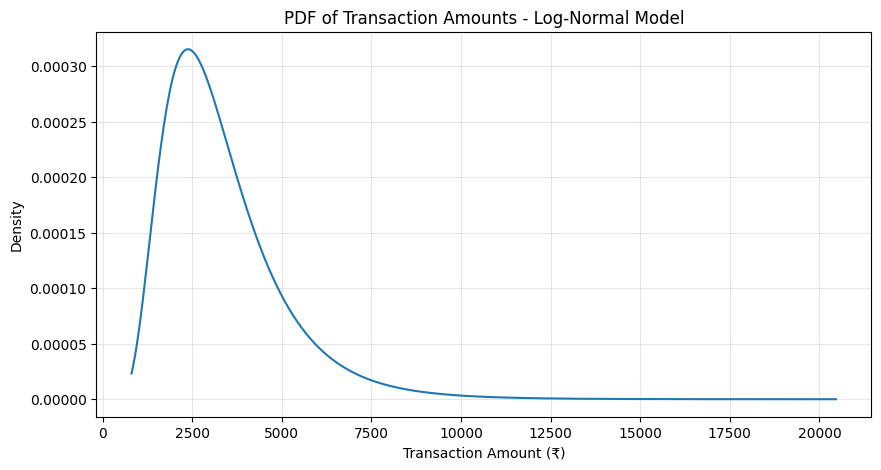

In [33]:
x = np.linspace(
    amounts.min(),
    amounts.max(),
    500)
pdf_values = stats.lognorm.pdf(
    x,
    log_shape,
    loc=log_loc,
    scale=log_scale)
plt.figure(figsize=(10, 5))
plt.plot(x, pdf_values)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Density")
plt.title("PDF of Transaction Amounts - Log-Normal Model")
plt.grid(alpha=0.3)
plt.show()

**CDF**

**CDF = Cumulative Distribution Function.**

Ye batata hai:given value tak kitna cumulative probability/data portion aa chuka hai.

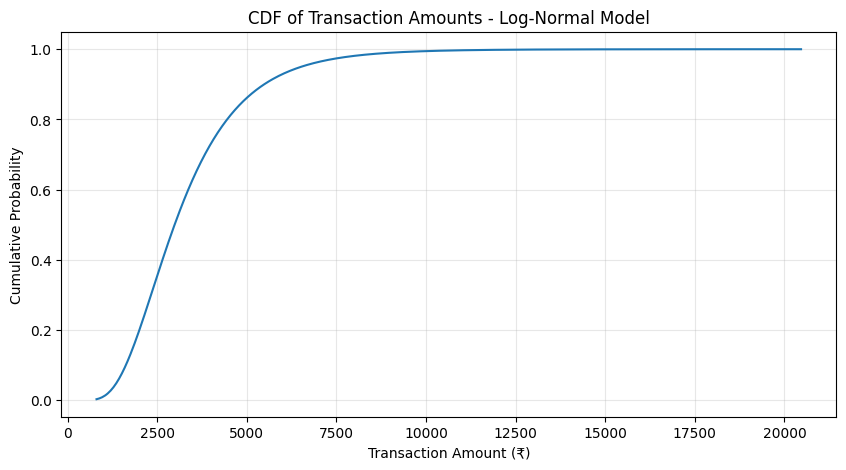

In [34]:
cdf_values = stats.lognorm.cdf(
    x,
    log_shape,
    loc=log_loc,
    scale=log_scale
)

plt.figure(figsize=(10, 5))
plt.plot(x, cdf_values)

plt.xlabel("Transaction Amount (₹)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Transaction Amounts - Log-Normal Model")
plt.grid(alpha=0.3)
plt.show()

## ₹5000 ka CDF

In [35]:
cdf_5000 = stats.lognorm.cdf(
    5000,
    log_shape,
    loc=log_loc,
    scale=log_scale
)

print("CDF at ₹5000:", round(cdf_5000, 4))
print("Probability above ₹5000:",
      round(1 - cdf_5000, 4))

CDF at ₹5000: 0.8616
Probability above ₹5000: 0.1384


# CONCLUSION

The PDF shows the density of transaction amounts across different
amount ranges.

The CDF shows the cumulative probability of observing a transaction
amount up to a particular value.

For ₹5000, the fitted Log-Normal model estimates that approximately
13.84% of transactions may exceed this amount.

**8. Conclude which distribution best fits the dataset and justify insights for decision-makin**g.

# Final Conclusion

The transaction dataset was analysed using several probability
distributions and statistical techniques.

1. The transaction status was represented using a Bernoulli distribution.
   The success probability was approximately 44.55%.

2. Weekly transaction counts were approximately modelled using a
   Binomial distribution. Because weekly totals do not naturally have
   a fixed number of trials, this fit was treated as an approximation.

3. Daily transaction counts were fitted using a Poisson distribution.
   The average number of transactions per day was approximately 7.10.

4. Transaction amounts showed strong positive skewness and were not
   normally distributed.

5. Both Log-Normal and Power Law models were considered for transaction
   amounts. Based on the calculated AIC values, the Log-Normal model
   provided a better relative fit for this dataset.

6. The Q-Q plot and Shapiro-Wilk test confirmed that the original
   transaction amounts do not follow a normal distribution.

7. The Box-Cox transformation substantially improved the symmetry and
   normality of the transaction amount data.

8. The Z-score of ₹5000 was approximately 0.82. The normal approximation
   gave an upper-tail probability of about 20.52%, while the actual
   observed proportion above ₹5000 was about 11.36%.

9. The PDF and CDF plots helped visualize the distribution and cumulative
   behaviour of transaction amounts.

Overall, the transaction amount data is better described by a
right-skewed Log-Normal type distribution than by a normal distribution
or the simple Power Law model tested here.